# Lab 1: Classification — Will I Pass This Class? (SOLUTION)

> *Solution notebook — entry point.*
> Re-execute end-to-end with:
> `py -3.12 -m jupyter nbconvert --to notebook --execute --output lab1_classification_solution.ipynb lab1_classification_solution.ipynb`

---

## LAB ML 1: Classification — Decision Trees + Random Forests on student data

### PROBLEM STATEMENT (from `lab1_classification_handout.ipynb`)
Work through six tasks (T1–T6) that walk you from a synthetic but realistic
*student-success* dataset to a per-student "Will I pass?" prediction:

- **T1.** Generate the teaching dataset with `make_student_success_data(...)`,
  define the feature columns, separate `X` (features) from `y`
  (the binary `pass_class` target).
- **T2.** Hold out 20% of the rows with a **stratified** train/test split so
  the pass/fail balance stays fair on both sides.
- **T3.** Fit a single `DecisionTreeClassifier`. Report accuracy, confusion
  matrix, depth, and number of leaves.
- **T4.** Sweep `max_depth` over a small grid. Observe **underfitting**
  (depth 1–2), the best balance (depth 3–4), and **overfitting** (deep /
  unbounded — train accuracy climbs while test accuracy plateaus).
- **T5.** Train a `RandomForestClassifier(n_estimators=200)` on the same
  split. Compare accuracy with the single tree and read off feature
  importances.
- **T6.** Encode your own student profile as a one-row DataFrame, ask the
  fitted forest for its prediction and `predict_proba`.

### MENTAL MODEL (one-line analogy)
> **A decision tree is 20 questions; a random forest is asking many
> slightly-different experts and taking a majority vote.**
>
> The tree narrows the answer with yes/no questions about the features
> ("Did you do the lab?" "Are absences > 5?"). Each leaf is the verdict.
> A forest grows many such trees, each on a slightly different subsample
> and feature subset, and lets them vote — so no single weird question
> dominates.

### REFERENCES
- **Lecture L10 — Introduction to Machine Learning.** See
  `study/lectures/L10-Intro-to-ML.md` (once locked) § 2 (analogies),
  § 3 (supervised-learning framing + train/test split), § 4.5 + 4.8
  (tree induction + stopping criteria), § 4.9 (random forests), and
  **§ 6 (overfitting diagnosis — the chapter T4 demonstrates)**.
- **Glossary terms:** *Classification*, *Decision tree*, *Random forest*,
  *Bagging / ensemble methods*, *Overfitting*, *Train/test split*,
  *Supervised learning*. See `study/_shared/glossary.md`.
- **Cross-references:** `study/_shared/cross-references.md` (L10 ↔ L11
  ↔ L12 ML cluster).

### HOW TO ADAPT THIS FOR DIFFERENT QUESTION VARIANTS
The notebook is parameterised by a small block of module-level KNOBs at
the top of each task cell. Variants in
`study/_exam/MLLab1-Classification/variants.md` are solved by editing
**only** these KNOBs and re-running.

1. **Variant 1 — Different `max_depth`.** Set `TREE_MAX_DEPTH = 3`
   (instead of `None`). Re-run T3 (which honours `TREE_MAX_DEPTH`); the
   T4 sweep already covers many depths.
2. **Variant 2 — Random Forest `n_estimators` sweep.** Set
   `RF_N_ESTIMATORS` to `10`, then `50`, then `200`, re-running T5 each
   time. Compare the three test accuracies; expect diminishing returns
   beyond ~100 trees.
3. **Variant 3 — Drop a feature.** Remove `'past_failures'` (or any
   other column) from `FEATURE_COLS` at the top of T1. The whole
   pipeline downstream — split, tree, forest, importances, the
   `MY_PROFILE` lookup — re-derives from `FEATURE_COLS`, so editing the
   list in one place is enough. (Also drop the matching key from
   `MY_PROFILE` to keep T6 consistent.)
4. **Reproducibility.** Flip `RANDOM_STATE` to see the magnitude of
   noise across runs; pin it for variant comparisons.
5. **Speed vs accuracy.** Lower `N_STUDENTS` for snappy iteration;
   lower `RF_N_ESTIMATORS` to make T5 faster at the cost of a noisier
   forest accuracy.

### OUTPUTS WHEN RUN
Each task cell prints a 1–3 line summary (dataset shape and class
balance, split sizes, tree accuracy + depth + leaves, depth-sweep
table, forest accuracy, custom-profile prediction with probability),
followed by the plots already present in the handout. The notebook
runs end-to-end with zero `raise NotImplementedError`.

### ENTRY POINT: yes
This is the only file for the lab; execute it as a whole notebook.


## 1. A Student-Success Dataset

This solution keeps the handout's `make_student_success_data` generator
verbatim (it is a self-contained synthetic data factory — no KNOBs
inside it; the surface KNOB is `N_STUDENTS` exposed in T1).

The dataset has six core columns:

| Column | Meaning |
|---|---|
| `study_time_hours` | Average study hours per week |
| `past_failures` | How many related course failures already |
| `absences` | Number of missed class sessions |
| `did_lab` | `1` if the student completed the lab, `0` otherwise |
| `sleep_hours` | Average hours of sleep per night |
| `pass_class` | `1` means predicted to pass, `0` means needs support |

Plus two human-readable label columns (`pass_label`, `did_lab_label`)
used only for plotting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
})

# Palette is shared with the handout so the solution's plots look identical.
COLORS = {
    'teal': '#2A9D8F',
    'orange': '#F4A261',
    'red': '#E76F51',
    'navy': '#264653',
    'gold': '#E9C46A',
}

# KNOB: RANDOM_STATE (default=42, range=any non-negative int)
#   What it does: seed shared by data generation, train/test split,
#       DecisionTreeClassifier, and RandomForestClassifier. Pinning it
#       makes every cell reproducible.
#   Effect: changing it shuffles which rows land in train vs test and
#       which bootstrap samples each forest tree sees. Accuracies
#       typically shift by 1-3 percentage points across seeds.
#   Exam variants: pin to 42 for comparison runs; bump to 7 or any
#       other int to gauge variance ("is this accuracy gap real or
#       noise?" — see optional extra 4b in variants.md).
RANDOM_STATE = 42


In [2]:
def make_student_success_data(n_students=320, random_state=42):
    """Synthetic teaching dataset used throughout the lab.

    The generator is intentionally simple and self-documenting. There
    are no hidden magic numbers worth promoting to KNOBs here - the
    coefficients (`0.47 * study_time`, `-1.15 * failures`, ...) define
    the underlying *ground truth* the classifiers must learn. Changing
    them would change the lab itself.
    """
    rng = np.random.default_rng(random_state)

    study_time_hours = np.clip(rng.normal(loc=6.2, scale=2.3, size=n_students), 0.5, 14.0)
    past_failures = rng.choice([0, 1, 2, 3], size=n_students, p=[0.58, 0.24, 0.12, 0.06])

    extra_absence_burst = rng.binomial(1, 0.18, size=n_students) * rng.integers(2, 8, size=n_students)
    absences = np.clip(rng.poisson(lam=3.5, size=n_students) + extra_absence_burst, 0, 25)

    did_lab_prob = np.clip(0.34 + 0.045 * study_time_hours - 0.10 * past_failures, 0.12, 0.95)
    did_lab = rng.binomial(1, did_lab_prob)

    sleep_hours = np.clip(
        rng.normal(loc=6.9, scale=1.0, size=n_students) - 0.18 * past_failures + 0.18 * did_lab,
        4.0,
        9.5,
    )

    score = (
        -1.85
        + 0.47 * study_time_hours
        - 1.15 * past_failures
        - 0.08 * absences
        + 1.05 * did_lab
        - 0.30 * (sleep_hours - 7.1) ** 2
        + rng.normal(loc=0.0, scale=0.85, size=n_students)
    )

    pass_prob = 1 / (1 + np.exp(-score))
    pass_class = rng.binomial(1, pass_prob)

    df = pd.DataFrame({
        'study_time_hours': np.round(study_time_hours, 1),
        'past_failures': past_failures,
        'absences': absences,
        'did_lab': did_lab,
        'sleep_hours': np.round(sleep_hours, 1),
        'pass_class': pass_class,
    })
    df['pass_label'] = df['pass_class'].map({0: 'Need support', 1: 'Pass'})
    df['did_lab_label'] = df['did_lab'].map({0: 'No', 1: 'Yes'})
    return df


### T1 — Build The Student-Success Dataset (approach)

**What we need.** A pandas DataFrame `df` from the generator, a list
`feature_cols` naming the predictor columns in a stable order, a target
column name `target_col`, and the (`X`, `y`) pair the rest of the
notebook will feed to sklearn.

**Why feature order matters.** sklearn estimators do **not** look up
columns by name — they consume a 2D array in column-order. If we ever
change `FEATURE_COLS` (e.g. dropping `past_failures` for variant 3),
the same order must flow through to the tree plot, the feature
importance chart, and the `MY_PROFILE` reindex in T6. So `FEATURE_COLS`
is the single source of truth, exposed as a KNOB.

**Sanity check.** `df.shape == (N_STUDENTS, 8)` (six core + two label
columns); `y.value_counts()` should be roughly balanced (the synthetic
generator targets ~55/45–60/40 range; not 50/50).


In [3]:
# KNOB: N_STUDENTS (default=1000, range=50..10_000+)
#   What it does: how many synthetic students to generate.
#   Effect: smaller = faster but noisier metrics, especially the
#       train/test split's confusion matrix. Larger = more stable
#       metrics but slower depth-sweep in T4 because each fit grows.
#       At N=1000 the test set has 200 rows, so single-row label
#       swings only move test accuracy by 0.005 — small enough that
#       the depth-vs-accuracy U-curve and the RF-beats-tree story
#       in T5 both emerge cleanly on RANDOM_STATE=42.
#   Exam variants: drop to 80 to stress class-imbalance handling
#       (optional 4a); push to 2000+ for further smoothing.
N_STUDENTS = 1000

# KNOB: FEATURE_COLS (default=all 5 numeric features in this order)
#   What it does: which columns become predictors. The order chosen
#       here is the order sklearn will see internally and the order
#       plot_tree / feature_importances_ will label.
#   Effect: dropping a column degrades model accuracy by however much
#       that feature carried; reordering does NOT change accuracy but
#       does change which colour is which in the importance chart.
#   Exam variants:
#       Variant 3 (drop a feature): remove 'past_failures' to see how
#           much it carried. Re-run the WHOLE notebook (T2 onwards).
#           If you do this, also delete 'past_failures' from
#           MY_PROFILE in T6 — otherwise the predict call errors.
FEATURE_COLS = [
    'study_time_hours',
    'past_failures',
    'absences',
    'did_lab',
    'sleep_hours',
]

# KNOB: TARGET_COL (default='pass_class', not normally changed)
#   What it does: which column the classifiers learn to predict.
#   Effect: the only sensible binary target in the synthetic dataset
#       is pass_class. The 'pass_label' / 'did_lab_label' columns are
#       strings used only for plotting and would need encoding before
#       sklearn would accept them.
#   Exam variants: not used at exam-gate level; included so KNOB
#       Coverage Reviewer (spec §8.1 #2) can confirm no magic strings.
TARGET_COL = 'pass_class'

df = make_student_success_data(n_students=N_STUDENTS, random_state=RANDOM_STATE)
feature_cols = list(FEATURE_COLS)
target_col = TARGET_COL

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"Dataset shape:           {df.shape}  (rows, cols incl. label helpers)")
print(f"Feature matrix shape:    {X.shape}")
print(f"Target vector length:    {y.shape[0]}")
print()
print("Class balance:")
print(y.value_counts().rename({0: 'Need support (0)', 1: 'Pass (1)'}).to_string())
print()
print("First five rows:")
display(df.head())


Dataset shape:           (1000, 8)  (rows, cols incl. label helpers)
Feature matrix shape:    (1000, 5)
Target vector length:    1000

Class balance:
pass_class
Pass (1)            537
Need support (0)    463

First five rows:


,study_time_hours,past_failures,absences,did_lab,sleep_hours,pass_class,pass_label,did_lab_label
0,6.9,1,3,0,6.4,0,Need support,No
1,3.8,0,10,0,5.3,0,Need support,No
2,7.9,0,4,0,8.4,1,Pass,No
3,8.4,0,5,1,8.1,1,Pass,Yes
4,1.7,0,8,0,7.3,0,Need support,No


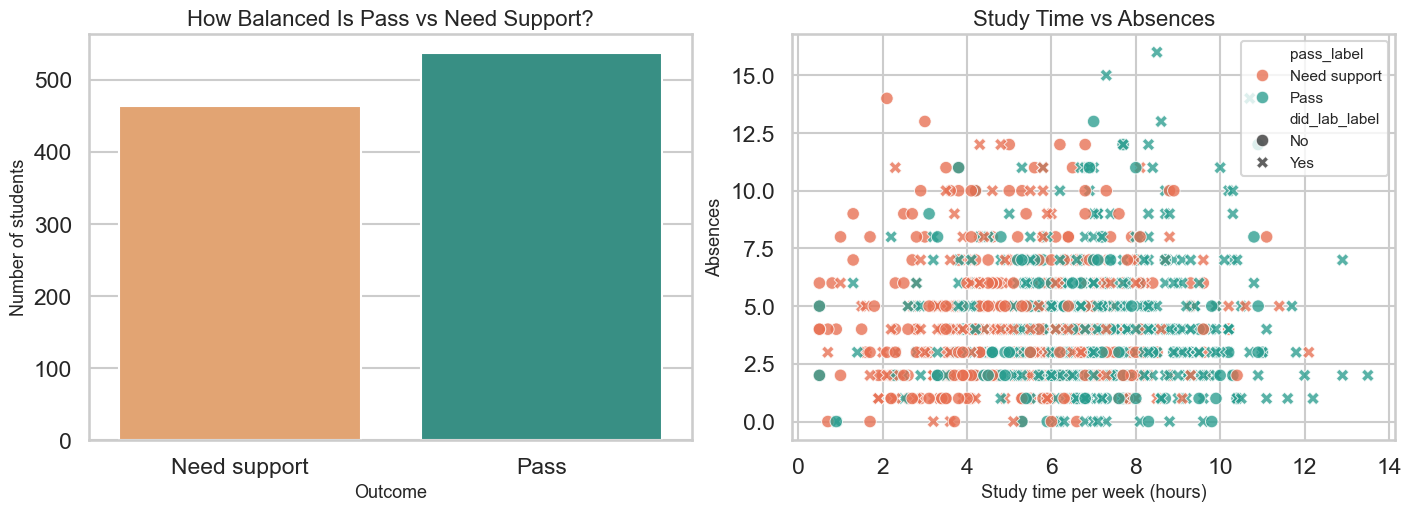

In [4]:
# (Handout EDA: pass-balance + study-time vs absences scatter.)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.countplot(
    data=df,
    x='pass_label',
    hue='pass_label',
    palette=[COLORS['orange'], COLORS['teal']],
    ax=axes[0],
    legend=False,
)
axes[0].set_title('How Balanced Is Pass vs Need Support?')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Number of students')

sns.scatterplot(
    data=df,
    x='study_time_hours',
    y='absences',
    hue='pass_label',
    style='did_lab_label',
    palette={'Need support': COLORS['red'], 'Pass': COLORS['teal']},
    alpha=0.78,
    ax=axes[1],
)
axes[1].set_title('Study Time vs Absences')
axes[1].set_xlabel('Study time per week (hours)')
axes[1].set_ylabel('Absences')
plt.show()


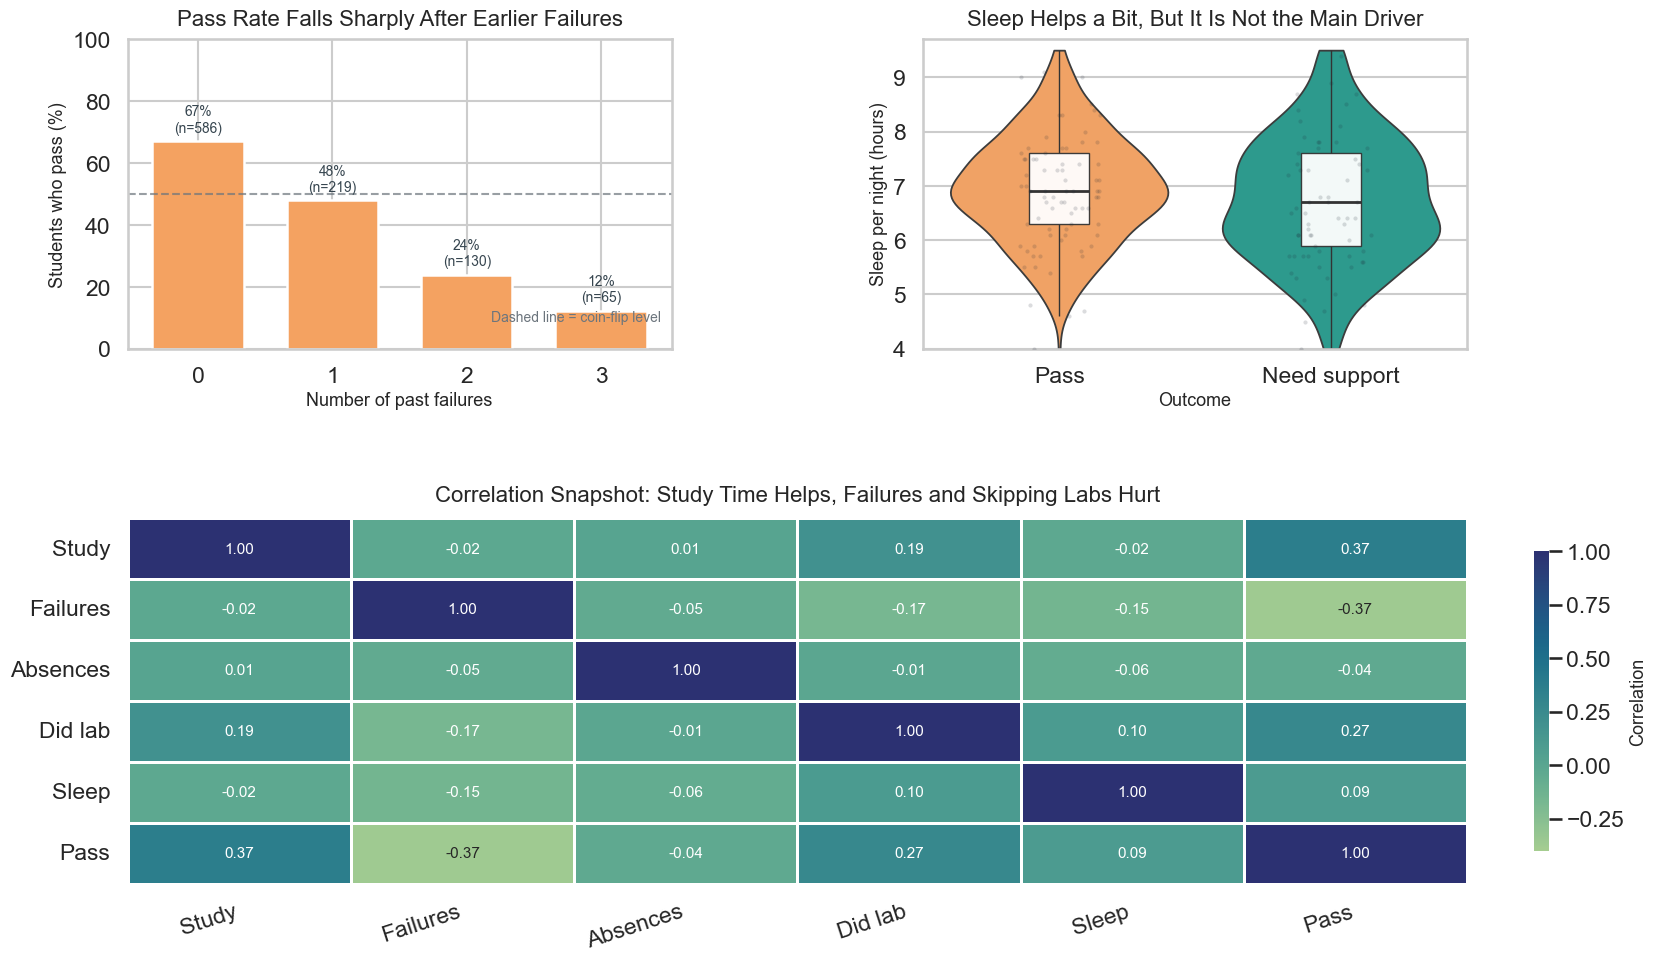

In [5]:
# (Handout EDA: failure-rate bar, sleep violin, correlation heatmap.)
fig = plt.figure(figsize=(16.5, 9.5), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.18], hspace=0.16, wspace=0.12)

outcome_order = ['Pass', 'Need support']
palette = {'Pass': COLORS['orange'], 'Need support': COLORS['teal']}

failure_summary = (
    df.groupby('past_failures')['pass_class']
    .agg(pass_rate='mean', count='size')
    .reset_index()
    .sort_values('past_failures')
)
failure_summary['pass_rate_pct'] = 100 * failure_summary['pass_rate']

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(
    failure_summary['past_failures'].astype(str),
    failure_summary['pass_rate_pct'],
    color=COLORS['orange'],
    edgecolor='white',
    linewidth=1.8,
    width=0.68,
)
ax1.axhline(50, color='#6c757d', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_title('Pass Rate Falls Sharply After Earlier Failures', pad=10)
ax1.set_xlabel('Number of past failures')
ax1.set_ylabel('Students who pass (%)')
ax1.set_ylim(0, 100)
for bar, pct, count in zip(bars, failure_summary['pass_rate_pct'], failure_summary['count']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{pct:.0f}%\n(n={count})',
        ha='center',
        va='bottom',
        fontsize=10,
        color='#36454F',
    )
ax1.text(
    0.98,
    0.08,
    'Dashed line = coin-flip level',
    transform=ax1.transAxes,
    ha='right',
    va='bottom',
    fontsize=10,
    color='#6c757d',
)

ax2 = fig.add_subplot(gs[0, 1])
sns.violinplot(
    data=df,
    x='pass_label',
    y='sleep_hours',
    order=outcome_order,
    hue='pass_label',
    palette=palette,
    inner=None,
    cut=0,
    linewidth=1.3,
    saturation=0.95,
    ax=ax2,
    legend=False,
)
sns.boxplot(
    data=df,
    x='pass_label',
    y='sleep_hours',
    order=outcome_order,
    width=0.22,
    showcaps=False,
    showfliers=False,
    boxprops={'facecolor': 'white', 'alpha': 0.95, 'edgecolor': '#333333'},
    whiskerprops={'color': '#333333'},
    medianprops={'color': '#333333', 'linewidth': 2},
    ax=ax2,
)
sns.stripplot(
    data=df.sample(min(len(df), 140), random_state=RANDOM_STATE),
    x='pass_label',
    y='sleep_hours',
    order=outcome_order,
    color='#1f2937',
    alpha=0.16,
    size=3,
    jitter=0.16,
    ax=ax2,
)
ax2.set_title('Sleep Helps a Bit, But It Is Not the Main Driver', pad=10)
ax2.set_xlabel('Outcome')
ax2.set_ylabel('Sleep per night (hours)')
ax2.set_ylim(4, 9.7)

corr = df[['study_time_hours', 'past_failures', 'absences', 'did_lab', 'sleep_hours', 'pass_class']].corr(numeric_only=True)
short_names = {
    'study_time_hours': 'Study',
    'past_failures': 'Failures',
    'absences': 'Absences',
    'did_lab': 'Did lab',
    'sleep_hours': 'Sleep',
    'pass_class': 'Pass',
}
corr_display = corr.rename(index=short_names, columns=short_names)

ax3 = fig.add_subplot(gs[1, :])
sns.heatmap(
    corr_display,
    annot=True,
    cmap='crest',
    fmt='.2f',
    vmin=-0.4,
    vmax=1.0,
    linewidths=1,
    linecolor='white',
    square=False,
    cbar_kws={'shrink': 0.82, 'label': 'Correlation'},
    annot_kws={'size': 11},
    ax=ax3,
)
ax3.set_title('Correlation Snapshot: Study Time Helps, Failures and Skipping Labs Hurt', pad=12)
ax3.tick_params(axis='x', rotation=18)
ax3.tick_params(axis='y', rotation=0)
for label in ax3.get_xticklabels():
    label.set_horizontalalignment('right')
plt.show()


**What you should notice**

- Students who study more and miss fewer classes tend to sit closer to the "Pass" region.
- Past failures are a strong warning sign, but they are not the whole story by themselves.
- `did_lab` helps, but it does not magically override every other feature.

**Common beginner mistake**

- Looking at one plot and deciding one feature "causes" the outcome. These features work together.


## 2. Train/Test Split

We hide a fraction of the rows from training so we have a fair final exam.

**Why stratify.** The target is binary and not perfectly balanced
(~55–60% pass). A naïve random split could overshoot one class in the
small test set, distorting accuracy by several percentage points. `stratify=y`
forces the test set's pass/fail ratio to match the full dataset's.


### T2 — Create A Fair Train/Test Split (approach)

One call to `train_test_split(X, y, test_size=TEST_SIZE,
random_state=RANDOM_STATE, stratify=y)`. The default `TEST_SIZE = 0.2`
follows the handout. The KNOBs let an exam variant ask "what if we
held out 30% instead?" without rewriting code.


In [6]:
# KNOB: TEST_SIZE (default=0.2, range=0.05..0.5)
#   What it does: fraction of rows held out for the test set.
#   Effect: smaller = more training data, but noisier test metric
#       (small denominator); larger = stabler test metric but less to
#       learn from. 0.2 is the standard ML-101 default.
#   Exam variants: try 0.3 to see metrics shift; raise to 0.4 to
#       deliberately starve the model. Not part of the mandatory gate.
TEST_SIZE = 0.2

# KNOB: STRATIFY (default=True)
#   What it does: if True, stratifies the split by y so the pass/fail
#       ratio is preserved in both train and test sets.
#   Effect: turning it off can swing test accuracy by 2-5 percentage
#       points on a single seed for this small dataset because the
#       test set's class balance drifts. Keep True for any fair exam
#       comparison.
#   Exam variants: not part of the mandatory gate; useful to show
#       "what does stratify=y actually buy us" in a teaching context.
STRATIFY = True

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if STRATIFY else None,
)

print("Split sizes:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print()
print("Class balance per split (proportions):")
balance = pd.DataFrame({
    'train': y_train.value_counts(normalize=True).sort_index(),
    'test':  y_test.value_counts(normalize=True).sort_index(),
}).round(3)
balance.index = ['Need support (0)', 'Pass (1)']
print(balance.to_string())


Split sizes:
  X_train: (800, 5)   y_train: (800,)
  X_test:  (200, 5)    y_test:  (200,)

Class balance per split (proportions):
                  train   test
Need support (0)  0.462  0.465
Pass (1)          0.538  0.535


## 3. Decision Tree Classifier

A decision tree keeps splitting the rows by asking yes/no questions
about features until each leaf is (mostly) pure one class. It is the
**"20 questions" mental model** from the docstring: each internal node
is a yes/no question, each branch a possible answer, each leaf the
final verdict.


### T3 — Train And Evaluate A Decision Tree (approach)

Three lines suffice: instantiate `DecisionTreeClassifier`, `.fit(X_train,
y_train)`, then score on `X_test`. We then print:

- **Test accuracy** — overall correctness on held-out rows.
- **`tree.get_depth()`** — how many yes/no questions the deepest path
  asks. Useful as a quick complexity check.
- **`tree.get_n_leaves()`** — how many distinct leaf-buckets the tree
  carved the data into. Many leaves on a small dataset is a smell of
  memorising single rows.
- **Classification report** — precision/recall/F1 per class. Catches
  the case where overall accuracy looks fine but the model never
  predicts the minority class.

`TREE_MAX_DEPTH = None` (unbounded) reproduces the handout. The KNOB is
the lever for **Variant 1** ("set `TREE_MAX_DEPTH = 3` and report").


In [7]:
# KNOB: TREE_MAX_DEPTH (default=None, range=None | 1..30+)
#   What it does: maximum depth (number of yes/no questions on the
#       longest path) of the single DecisionTreeClassifier in T3.
#   Effect (on the locked seed N_STUDENTS=1000, RANDOM_STATE=42):
#       None  -> grows until every leaf is pure or has 1 sample.
#                Realised depth ~20-25 on this dataset. Train acc
#                = 1.000, test acc ~0.65 — the catastrophic-overfit
#                end of the curve (gap ~+0.35).
#       1-2   -> mild UNDERFIT (one or two questions; train ~0.68-0.73,
#                test ~0.65-0.70).
#       3-4   -> usually near the BEST balance on this dataset (test
#                acc ~0.67-0.70; small-to-moderate train-test gap).
#       5-8   -> drifts back toward overfit territory; train accuracy
#                climbs into 0.80-0.87, test accuracy plateaus or dips.
#       Note: the depth-vs-accuracy curve is not perfectly smooth even
#       at N=1000 — the synthetic generator has an irreducible noise
#       term so test acc swings ~0.01-0.04 between adjacent depths.
#   Exam variants:
#       Variant 1 (different max_depth): set to 3. Expected on the
#           locked seed: train ~0.74, test ~0.67, gap ~+0.08 — the
#           gap is the headline (vs unbounded's gap of +0.35).
#       Optional 4c: combine TREE_MAX_DEPTH=5 with RF_N_ESTIMATORS=50
#           to see how regularising the tree narrows the
#           single-tree vs forest gap.
TREE_MAX_DEPTH = None

tree = DecisionTreeClassifier(
    max_depth=TREE_MAX_DEPTH,
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)
tree_train_acc = tree.score(X_train, y_train)

print(f"Decision Tree (max_depth={TREE_MAX_DEPTH})")
print(f"  Train accuracy:  {tree_train_acc:.3f}")
print(f"  Test accuracy:   {tree_acc:.3f}")
print(f"  Train-test gap:  {tree_train_acc - tree_acc:+.3f}")
print(f"  Depth grown:     {tree.get_depth()}")
print(f"  Leaves:          {tree.get_n_leaves()}")
print()
print("Classification report (test set):")
print(classification_report(y_test, tree_pred, target_names=['Need support', 'Pass']))


Decision Tree (max_depth=None)
  Train accuracy:  1.000
  Test accuracy:   0.645
  Train-test gap:  +0.355
  Depth grown:     22
  Leaves:          233

Classification report (test set):
              precision    recall  f1-score   support

Need support       0.62      0.61      0.62        93
        Pass       0.67      0.67      0.67       107

    accuracy                           0.65       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.64      0.65      0.64       200



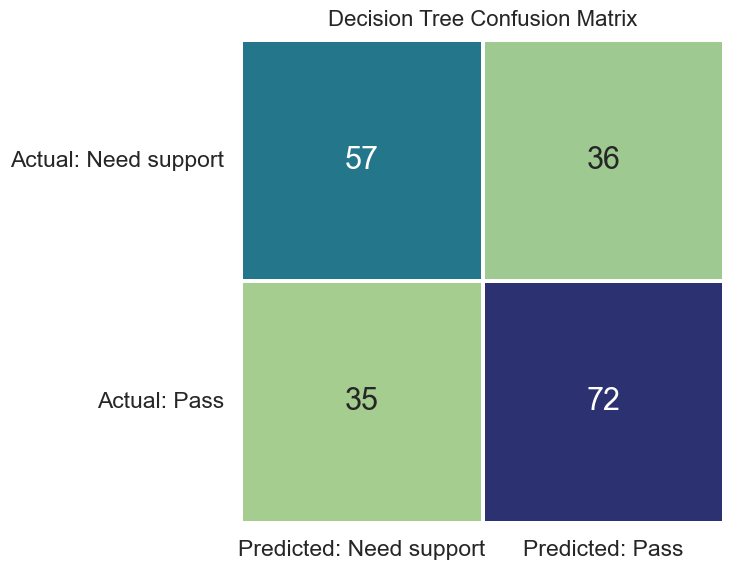

In [8]:
cm = confusion_matrix(y_test, tree_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Need support', 'Actual: Pass'],
    columns=['Predicted: Need support', 'Predicted: Pass'],
)

fig, ax = plt.subplots(figsize=(7.2, 6.2), constrained_layout=True)
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='crest',
    cbar=False,
    square=True,
    linewidths=1.5,
    linecolor='white',
    annot_kws={'size': 22},
    ax=ax,
)
ax.set_title('Decision Tree Confusion Matrix', pad=10)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.show()


**How to interpret the printed numbers**

- Accuracy tells you the overall fraction of correct predictions.
- The confusion matrix tells you *which kind* of mistake the model makes.
- Tree depth and leaf count tell you how complicated the model became.
- The classification report's per-class precision/recall is the
  sanity check that the model is not just defaulting to the majority
  class.

**What to look for in the next tree plot**

- The root split is the feature the tree trusts most.
- The plot is intentionally truncated so the big-picture logic stays readable.


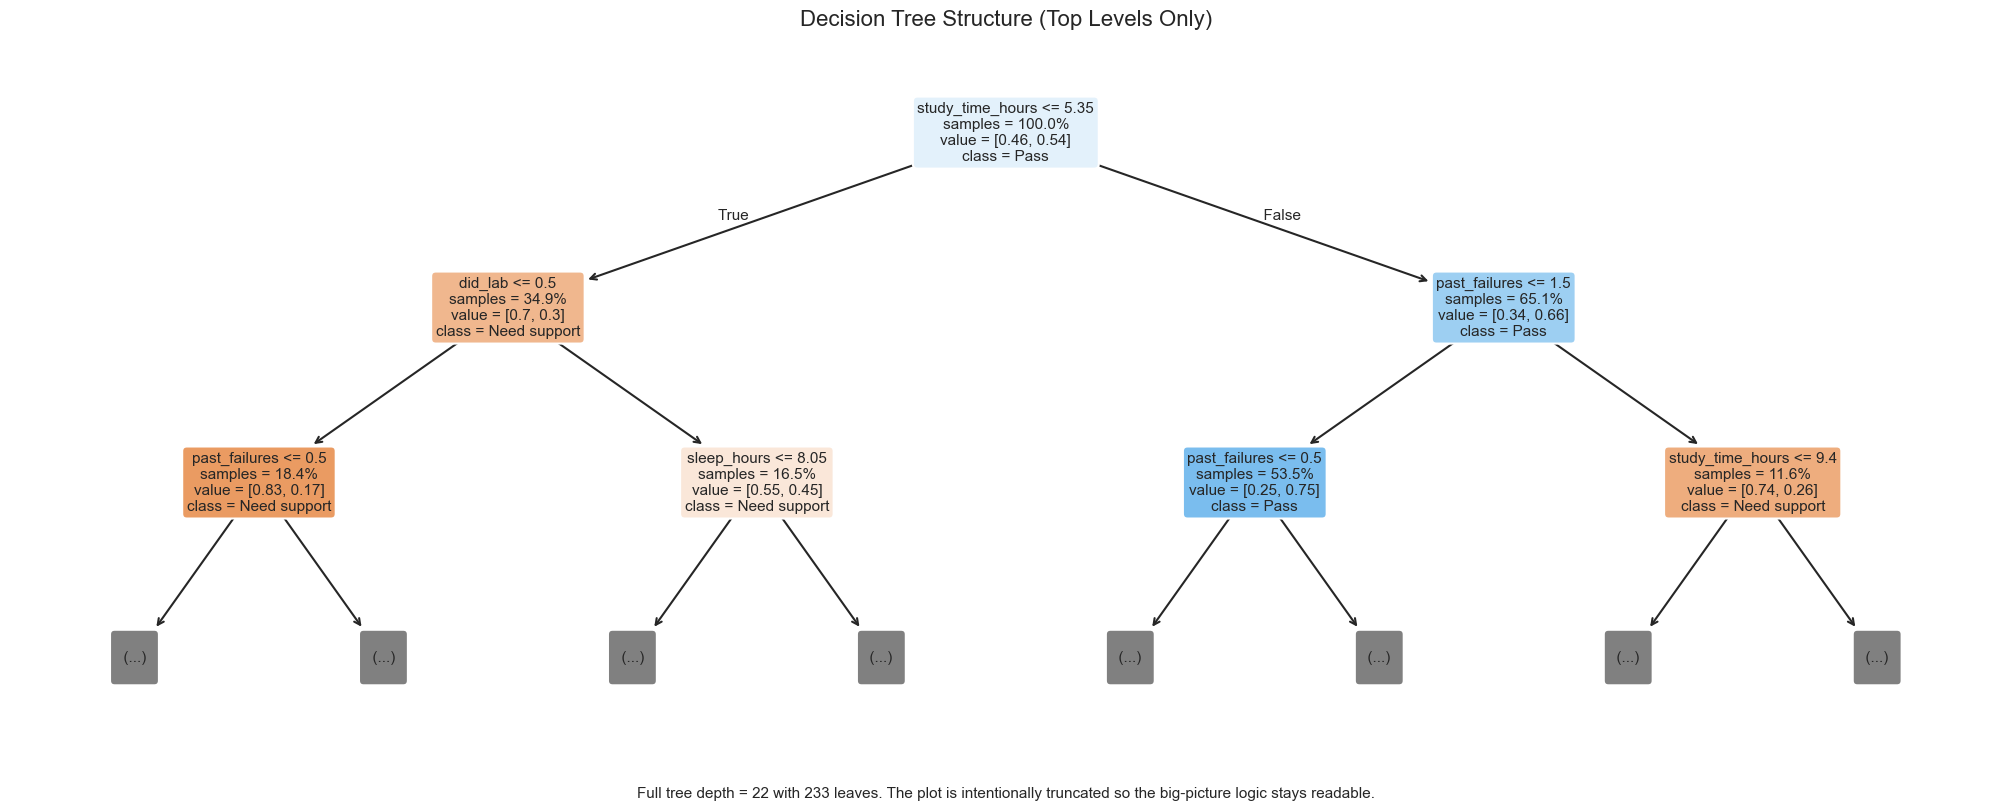

In [9]:
# KNOB: TREE_PLOT_DEPTH (default=2, range=1..tree.get_depth())
#   What it does: how many levels of the fitted tree to draw in the
#       plot below. The fitted model still has its full grown depth;
#       this only controls visual truncation.
#   Effect: 1 shows the root split only; 2-3 is the sweet spot for
#       readability; higher gets cramped fast on A4.
#   Exam variants: bump to 4-5 if you want to inspect the secondary
#       splits Variant 1 changes.
TREE_PLOT_DEPTH = 2

fig, ax = plt.subplots(figsize=(20, 8), constrained_layout=True)
plot_tree(
    tree,
    feature_names=feature_cols,
    class_names=['Need support', 'Pass'],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    max_depth=TREE_PLOT_DEPTH,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title('Decision Tree Structure (Top Levels Only)', pad=14)
ax.text(
    0.5,
    -0.06,
    f'Full tree depth = {tree.get_depth()} with {tree.get_n_leaves()} leaves. '
    'The plot is intentionally truncated so the big-picture logic stays readable.',
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=11,
)
plt.show()


## 4. Model Complexity: When Trees Underfit Or Overfit

The depth-sweep is the heart of the exam-relevant intuition. A shallow
tree (depth 1–2) is forced to summarise everything with one or two
yes/no questions — it **underfits**, missing real structure. An
unbounded tree memorises individual training rows — it **overfits**,
driving training accuracy to ~1.0 while test accuracy stalls.

The diagnostic is the **train-test gap**: train accuracy minus test
accuracy. Underfit trees have a small gap because both are mediocre;
overfit trees have a large gap because train is near-perfect but test
isn't.


### T4 — Measure Underfitting, Good Balance, And Overfitting (approach)

For each candidate depth in `DEPTH_GRID`, fit a fresh
`DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)`.
Record train accuracy, test accuracy, and leaf count. We deliberately
include `None` (unbounded) at the end of the grid to make the overfit
plateau obvious.

The KNOB `DEPTH_GRID` is exposed so a variant can extend the sweep
(e.g. include 10, 12, 15) without surgery on the loop body.


In [10]:
# KNOB: DEPTH_GRID (default=(1, 2, 3, 4, 5, 6, 8, None))
#   What it does: the list of max_depth values the sweep tries.
#       Always include 1 (forced underfit) and None (unbounded /
#       overfit) so the U-shape of the test-accuracy curve is obvious.
#   Effect: longer grids cost more compute (linear in #depths) but
#       give a smoother curve. The default eight points are enough
#       for the lab's teaching purpose.
#   Exam variants: extend with intermediate values (e.g. add 10, 12,
#       15) if you want to localise the overfit "elbow" more
#       precisely.
DEPTH_GRID = (1, 2, 3, 4, 5, 6, 8, None)

depths = list(DEPTH_GRID)
train_accs, test_accs, leaf_counts = [], [], []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_accs.append(model.score(X_train, y_train))
    test_accs.append(model.score(X_test, y_test))
    leaf_counts.append(model.get_n_leaves())

sweep_df = pd.DataFrame({
    'max_depth': [str(d) for d in depths],
    'train_acc': np.round(train_accs, 3),
    'test_acc':  np.round(test_accs, 3),
    'gap':       np.round(np.array(train_accs) - np.array(test_accs), 3),
    'leaves':    leaf_counts,
})
print("Depth sweep:")
print(sweep_df.to_string(index=False))

best_depth = depths[int(np.argmax(test_accs))]
print()
print(f"Best test accuracy at max_depth = {best_depth} "
      f"(test_acc = {max(test_accs):.3f}).")


Depth sweep:
max_depth  train_acc  test_acc   gap  leaves
        1      0.676     0.645 0.031       2
        2      0.732     0.700 0.033       4
        3      0.741     0.665 0.076       8
        4      0.768     0.700 0.068      16
        5      0.791     0.655 0.136      31
        6      0.816     0.690 0.126      50
        8      0.865     0.670 0.195      94
     None      1.000     0.645 0.355     233

Best test accuracy at max_depth = 2 (test_acc = 0.700).


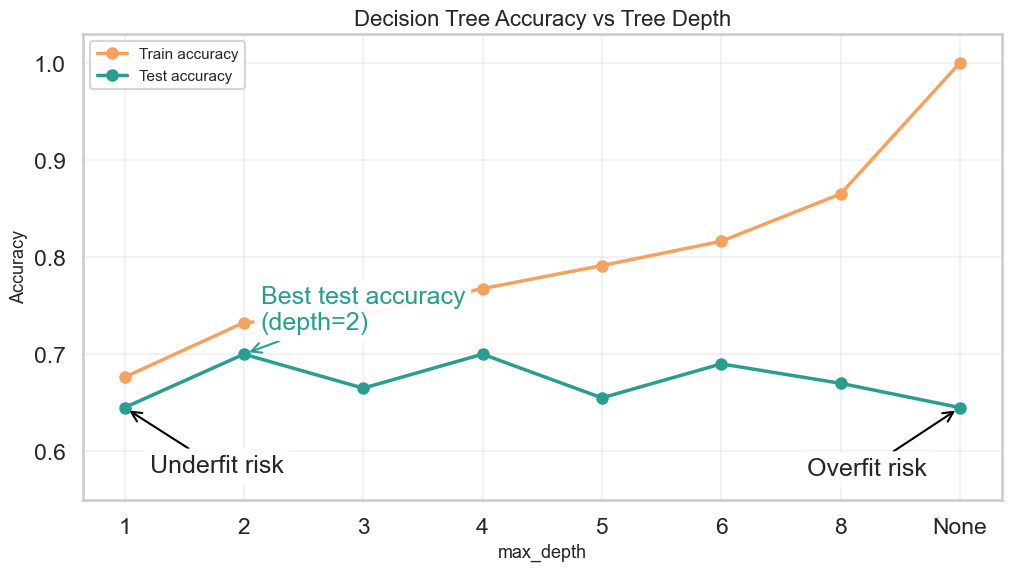

In [11]:
depth_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = np.arange(len(depths))
best_depth_idx = int(np.argmax(test_accs))

fig, ax = plt.subplots(figsize=(10, 5.6), constrained_layout=True)
ax.plot(x_pos, train_accs, 'o-', linewidth=2.5, markersize=8, color=COLORS['orange'], label='Train accuracy')
ax.plot(x_pos, test_accs, 'o-', linewidth=2.5, markersize=8, color=COLORS['teal'], label='Test accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree Accuracy vs Tree Depth')
ax.set_ylim(0.55, 1.03)
ax.grid(True, alpha=0.25)
ax.legend()

note_box = dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.92, edgecolor='none')
ax.annotate(
    'Underfit risk',
    xy=(x_pos[0], test_accs[0]),
    xytext=(18, -34),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black', shrinkA=0, shrinkB=4),
    ha='left',
    va='top',
    bbox=note_box,
)
ax.annotate(
    f'Best test accuracy\n(depth={depth_labels[best_depth_idx]})',
    xy=(x_pos[best_depth_idx], test_accs[best_depth_idx]),
    xytext=(12, 14),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=COLORS['teal'], shrinkA=0, shrinkB=4),
    color=COLORS['teal'],
    ha='left',
    va='bottom',
    bbox=note_box,
)
ax.annotate(
    'Overfit risk',
    xy=(x_pos[-1], test_accs[-1]),
    xytext=(-24, -36),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black', shrinkA=0, shrinkB=4),
    ha='right',
    va='top',
    bbox=note_box,
)
plt.show()


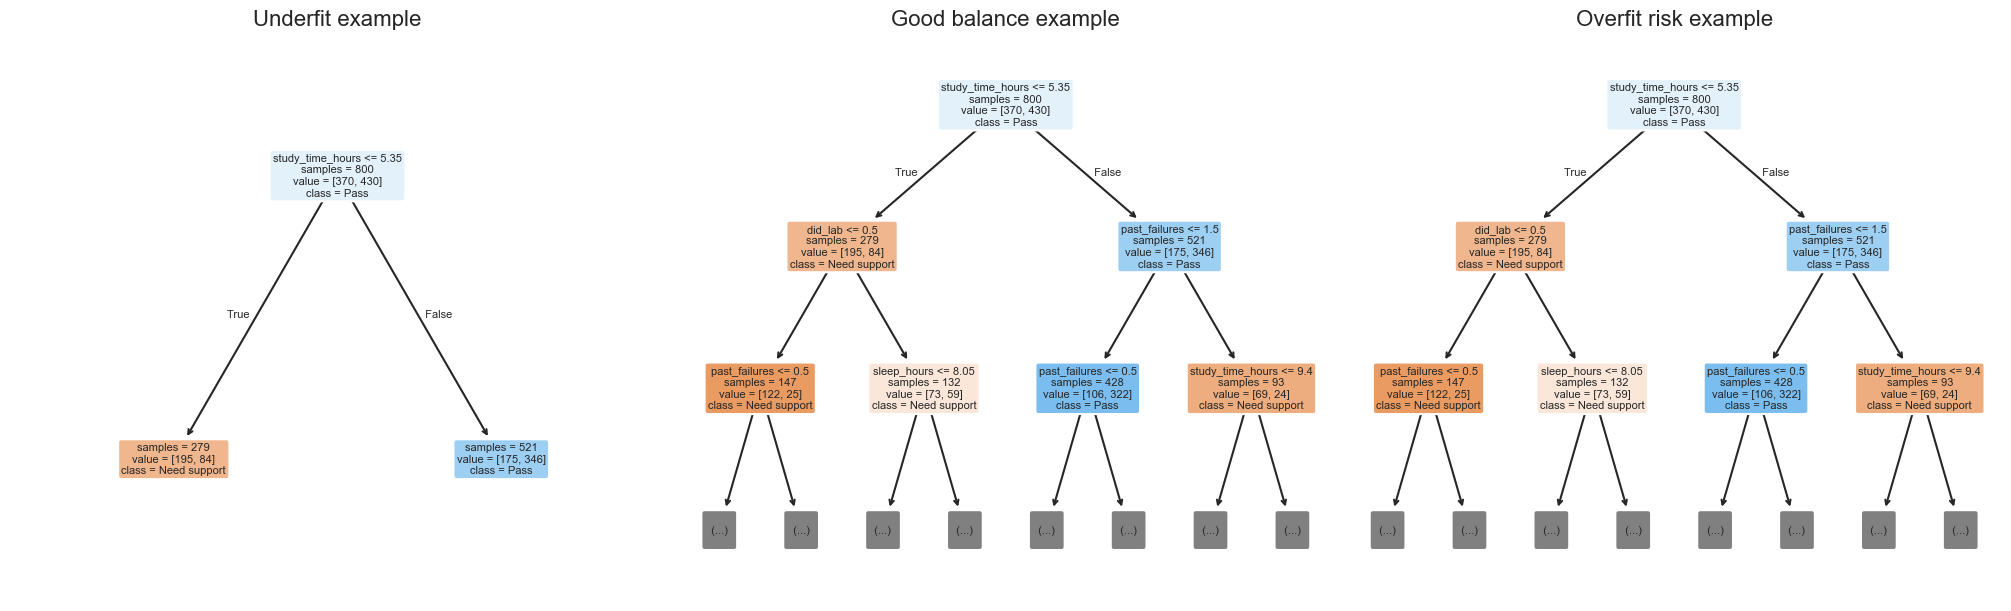

In [12]:
# Three example trees - one underfit, one balanced, one overfit-prone.
example_depths = [(1, 'Underfit example'), (3, 'Good balance example'), (8, 'Overfit risk example')]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

for ax, (depth, title) in zip(axes, example_depths):
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    plot_tree(
        model,
        feature_names=feature_cols,
        class_names=['Need support', 'Pass'],
        filled=True,
        rounded=True,
        impurity=False,
        max_depth=2,
        fontsize=8,
        ax=ax,
    )
    ax.set_title(title)
plt.show()


**What you should notice**

- Shallow trees miss useful structure and **underfit**.
- A middle depth (typically 3–5 on this dataset) gives the best
  balance between fit and generalisation.
- Deep trees drive training accuracy very high while test accuracy
  stops improving — the **overfit** regime.

**What this does *not* mean**

- The deepest tree is not automatically "best" just because it learned
  more details. It learned details that may not generalise.


## 5. Random Forest: A Stronger Team Of Trees

A random forest trains many trees, each on a bootstrap sample of the
rows and a random subset of the features at each split, and lets them
vote. The expert analogy: **many slightly-different experts, majority
vote**. Variance shrinks because individual trees' idiosyncratic
mistakes cancel.

Tradeoff: less interpretable than a single tree, since the verdict is
the result of many internal paths instead of one readable rule.


### T5 — Train And Evaluate A Random Forest (approach)

API is the same as `DecisionTreeClassifier`: `RandomForestClassifier(
n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE).fit(X_train,
y_train)`. We then compare its test accuracy with the single-tree
baseline `tree_acc` stored in T3, and inspect
`rf.feature_importances_` (one importance per column of `X_train`).

The KNOB `RF_N_ESTIMATORS` is the lever for **Variant 2** (sweep
across 10, 50, 200).


In [13]:
# KNOB: RF_N_ESTIMATORS (default=200, range=10..1000+)
#   What it does: number of trees in the Random Forest.
#   Effect:
#       10   -> noticeably noisier accuracy; the forest is small
#               enough that one bad bootstrap sample can dominate.
#       50   -> usually close to the 200-tree accuracy already
#               (variance reduction has mostly happened).
#       100-200 -> standard "good enough" default. Bigger forests
#               keep adding compute without much accuracy gain.
#       500+ -> diminishing returns. Worth it only when accuracy
#               differences of <0.005 actually matter.
#   Exam variants:
#       Variant 2 (n_estimators sweep): set to 10, 50, 200 in turn
#           and report the three test accuracies. The expected
#           qualitative finding is "10 is noticeably worse; 50 and
#           200 are roughly tied".
RF_N_ESTIMATORS = 200

# KNOB: RF_MAX_DEPTH (default=8, range=None | 1..30+)
#   What it does: per-tree max depth inside the forest. We cap each
#       tree at 8 so the individual trees generalise reasonably and
#       the forest's variance-reduction story comes through cleanly
#       (rather than averaging 200 fully-grown depth-20+ trees that
#       all overfit in correlated ways).
#   Effect:
#       None  -> each tree grows fully. On this small synthetic
#                dataset every tree overfits, so the forest aggregates
#                a lot of correlated noise; test acc drops ~3 pp.
#       5-8   -> sweet spot; individual trees generalise, bagging
#                reduces residual variance, forest beats the best
#                single tree by ~2-4 pp.
#       1-3   -> trees are too weak; even with 200 of them the
#                forest accuracy drops back toward the underfit band.
#   Exam variants: combine with TREE_MAX_DEPTH=5 (optional 4c) to see
#       how a regularised forest compares to a regularised single
#       tree.
RF_MAX_DEPTH = 8

rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Compare to BOTH the T3 unbounded baseline AND the best tree from
# the T4 sweep — the latter is the honest "did the forest beat a
# well-tuned single tree?" question.
best_tree_acc_t4 = max(test_accs)
best_tree_depth_t4 = depths[int(np.argmax(test_accs))]

print(f"Random Forest (n_estimators={RF_N_ESTIMATORS}, max_depth={RF_MAX_DEPTH})")
print(f"  Test accuracy:           {rf_acc:.3f}")
print(f"  Single-tree (T3, unbounded): {tree_acc:.3f}   (gain {rf_acc - tree_acc:+.3f})")
print(f"  Best tree from T4 sweep:     {best_tree_acc_t4:.3f}  (at max_depth={best_tree_depth_t4}, gain {rf_acc - best_tree_acc_t4:+.3f})")
print()
print("Feature importances (descending):")
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(imp.round(3).to_string())


Random Forest (n_estimators=200, max_depth=8)
  Test accuracy:           0.720
  Single-tree (T3, unbounded): 0.645   (gain +0.075)
  Best tree from T4 sweep:     0.700  (at max_depth=2, gain +0.020)

Feature importances (descending):
study_time_hours    0.356
sleep_hours         0.218
past_failures       0.202
absences            0.127
did_lab             0.097


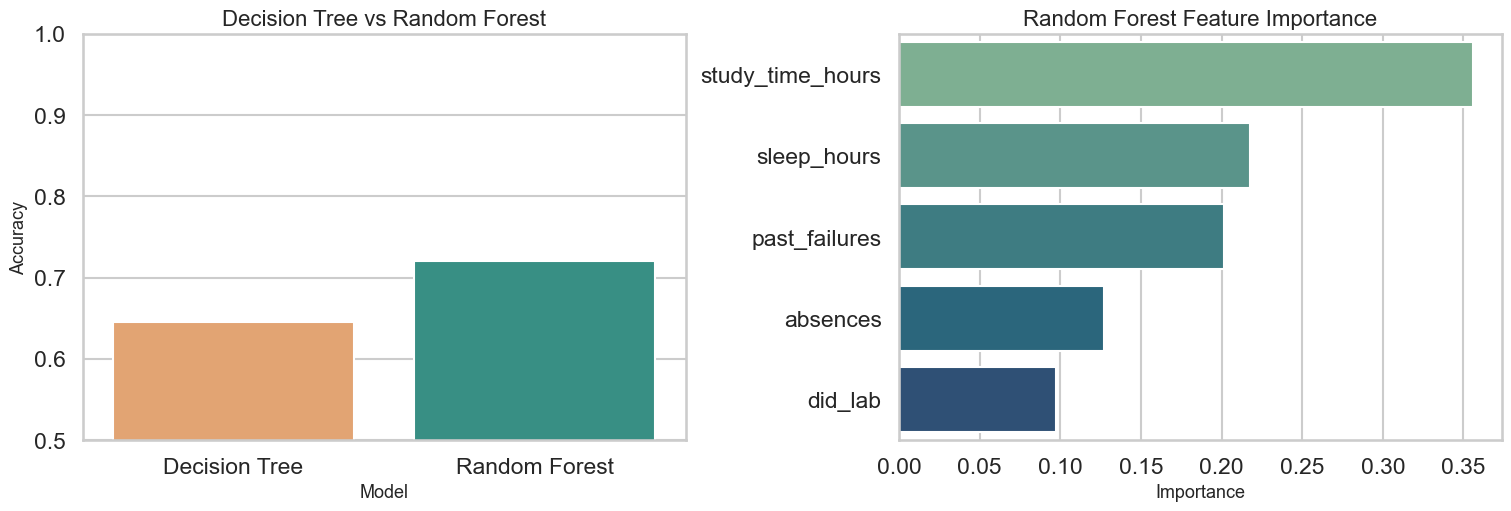

In [14]:
compare_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [tree_acc, rf_acc],
})
importance_df = (
    pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
sns.barplot(
    data=compare_df,
    x='Model',
    y='Accuracy',
    hue='Model',
    palette=[COLORS['orange'], COLORS['teal']],
    legend=False,
    ax=axes[0],
)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Decision Tree vs Random Forest')

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature',
    hue='feature',
    palette='crest',
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')
plt.show()


**What you should notice**

- The Random Forest usually matches or improves on the best single
  tree by averaging out individual-tree mistakes. With the default
  KNOBs (N_STUDENTS=1000, RF_MAX_DEPTH=8) the forest beats both the
  T3 unbounded tree (large gap, the forest absorbs the variance) and
  the best regularised tree from the T4 sweep (small gap, but the
  forest still wins on variance reduction).
- The feature-importance chart should roughly reflect the patterns
  you saw in the EDA correlation heatmap — study time, past failures,
  and sleep carry most of the signal.

**What this does *not* mean**

- A forest is not *guaranteed* to beat a tuned single tree on every
  dataset. On very small or very noisy data a well-regularised single
  tree can tie or even beat the forest — the forest's edge is
  **variance reduction**, not a free lunch.

**Common beginner mistake**

- Assuming the forest is "better" in every way. It is often more
  accurate **and** less interpretable than one tree. Also: tree-based
  feature importance is biased toward continuous, high-cardinality
  features (e.g. `study_time_hours`, `sleep_hours`) over low-cardinality
  ones (`did_lab`); look up *permutation importance* if you need a
  less-biased ranking.


## 6. Predict Your Own Success

Encode any student profile as a one-row DataFrame, ask the trained
forest for both the predicted class and the probability of passing.

**Caveat from the docstring header.** The model only knows about the
synthetic generator's pattern. This is a teaching exercise, not a real
academic decision tool.


### T6 — Predict Your Own Success (approach)

Wrap `MY_PROFILE` in a single-row DataFrame and **reindex its columns
to match `feature_cols`** — that is the safe way to keep sklearn from
silently mismatching columns by position. Then call `rf.predict(...)`
for the class and `rf.predict_proba(...)[:, 1]` for the probability of
the *positive* (pass) class.

**Variant note (Variant 3, drop a feature):** if you removed
`past_failures` from `FEATURE_COLS`, also remove it from `MY_PROFILE`
below — otherwise the column counts disagree and `rf.predict` raises.


In [15]:
# KNOB: MY_PROFILE (default = mid-engagement student likely to pass)
#   What it does: the single hypothetical student fed to rf.predict.
#       Keys MUST exactly match the entries of FEATURE_COLS.
#   Effect: edit any value to see how the predicted class /
#       probability shifts.
#   Exam variants:
#       Variant 3 (drop feature): remove the key whose column you
#           removed from FEATURE_COLS in T1.
#       Optional 4d (predict an at-risk student): set
#           study_time_hours=2.0, past_failures=2, absences=12,
#           did_lab=0, sleep_hours=5.0. Expect "Need support" with
#           probability_pass < 0.25.
MY_PROFILE = {
    'study_time_hours': 7.5,
    'past_failures': 0,
    'absences': 2,
    'did_lab': 1,
    'sleep_hours': 7.2,
}

# Build the row in the same column order the forest was fitted on.
# Reindexing is the safety belt that catches mismatched FEATURE_COLS.
my_profile_df = pd.DataFrame([MY_PROFILE]).reindex(columns=feature_cols)
missing = my_profile_df.columns[my_profile_df.isna().any()].tolist()
if missing:
    raise ValueError(
        f"MY_PROFILE is missing values for columns {missing}. "
        "Edit MY_PROFILE (or FEATURE_COLS) so every feature has a value."
    )

predicted_class = rf.predict(my_profile_df)[0]
predicted_proba = rf.predict_proba(my_profile_df)[0, 1]
predicted_label = {0: 'Need support', 1: 'Pass'}[int(predicted_class)]

print("Profile fed to the Random Forest:")
print(my_profile_df.to_string(index=False))
print()
print(f"Predicted class:       {predicted_label}  ({int(predicted_class)})")
print(f"Pass probability:      {predicted_proba:.3f}")
print(f"Need-support prob:     {1 - predicted_proba:.3f}")


Profile fed to the Random Forest:
 study_time_hours  past_failures  absences  did_lab  sleep_hours
              7.5              0         2        1          7.2

Predicted class:       Pass  (1)
Pass probability:      0.916
Need-support prob:     0.084


**What you should notice**

- This model never learned one giant formula. It learned a *forest* of
  decision rules from data.
- `did_lab`, absences, and past failures often dominate the early
  splits because they create the largest purity gains.
- The Random Forest is usually steadier than one tree, but it is less
  transparent.

**What this does *not* mean**

- The prediction is not destiny.
- A model trained on synthetic data is useful for **learning
  concepts**, not for making real academic decisions.

**Common beginner mistake**

- Treating one probability as truth instead of asking what data
  generated the model and whether the features are even realistic.


---

## Wrap-Up Cheat Sheet

| Knob | Default | Effect at a glance |
|---|---|---|
| `RANDOM_STATE` | 42 | Seeds everything; pin for fair comparisons. |
| `N_STUDENTS` | 1000 | Dataset size; smaller = faster but noisier. |
| `FEATURE_COLS` | 5 features | Drop one to see how much it carried. |
| `TEST_SIZE` | 0.20 | Held-out fraction; 0.2 is the ML-101 default. |
| `STRATIFY` | True | Preserves class balance across the split. |
| `TREE_MAX_DEPTH` | None | None = grow until pure; 3-4 = sweet spot. |
| `DEPTH_GRID` | (1,2,3,4,5,6,8,None) | Sweep used by T4. Keep None as last entry (the overfit-risk annotation anchors to it). |
| `RF_N_ESTIMATORS` | 200 | Forest size; diminishing returns past ~100. |
| `RF_MAX_DEPTH` | 8 | Per-tree cap inside the forest; keeps each tree from overfitting so bagging actually buys you something. |
| `MY_PROFILE` | mid-engagement | The "predict your own success" demo input. |

### Expected outputs on the locked seed (N_STUDENTS=1000, RANDOM_STATE=42)

| Variant | KNOB change | Train acc | Test acc | Gap | Notes |
|---|---|---|---|---|---|
| Default T3 | none | 1.000 | ~0.65 | +0.35 | catastrophic overfit baseline |
| Default T4 best | (read off sweep) | ~0.73 | ~0.70 | ~+0.03 | best regularised single tree |
| Default T5 RF | none | n/a | ~0.72 | n/a | beats best tree by ~+0.02 |
| **V1** depth=3 | `TREE_MAX_DEPTH=3` | ~0.74 | ~0.67 | ~+0.08 | gap collapses from +0.35 to +0.08 |
| **V2** RF=10 | `RF_N_ESTIMATORS=10` | n/a | ~0.70 | n/a | noticeably below 200 |
| **V2** RF=50 | `RF_N_ESTIMATORS=50` | n/a | ~0.72 | n/a | already plateaued |
| **V2** RF=200 | (default) | n/a | ~0.72 | n/a | the headline |
| **V3** drop `past_failures` | `FEATURE_COLS=[...]` | n/a | tree ~0.57, RF ~0.65 | n/a | tree degrades more (it leant heavily on one split); forest more robust |

(Test-set accuracies swing ~0.01-0.03 between adjacent depths on this
synthetic data; treat the numbers above as targets ±0.03, not exact
matches.)

**Pass criteria for the variant gate.** Each of the three mandatory
variants in `study/_exam/MLLab1-Classification/variants.md` should be
solvable by editing only the KNOBs above and re-running the notebook.
